# Chapter 2 — Descriptive Statistics

Pictures and numbers that summarize the shape, center, and spread of a data set.

| Section | What it covers |
|---|---|
| 2.1 | Histograms |
| 2.2 | Center and location |
| 2.3 | Box plots and skewness |
| 2.4 | Spread |

**How to use this notebook.** Read a short explanation, run the worked cell under it, then do the
**Your turn** cell yourself. The worked cells already show their output, so you can check your
answer against them. Nothing here is graded and nothing is hidden, so break things freely and
re-run the setup cell if you get lost.

The matching page on the website is [Descriptive Statistics](https://khh-aka-lucifer.github.io/statLab/chapters/descriptive-statistics/), where the same ideas are
sliders and draggable points instead of code. Use both. The website builds the intuition, and the
notebook shows you how to do it to data of your own.

In [1]:
# Run me first. Everything below needs this cell.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# The same colours the StatLab website uses, so your charts match the demos.
C = {
    "accent": "#2E7D6B", "accent_strong": "#1F5A4D", "accent_soft": "#D9EBE5",
    "ink": "#282725", "ink_soft": "#6B6560", "line": "#E4E0DA",
    "cat1": "#2E7D6B", "cat2": "#B5763F", "cat3": "#4E7DA6",
    "cat4": "#9A5D8F", "cat5": "#8A8F3C",
    "ok": "#4C8B57", "warn": "#C06A2E",
}

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": C["line"], "axes.labelcolor": C["ink"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C["line"], "grid.linewidth": 0.8,
    "text.color": C["ink"], "xtick.color": C["ink_soft"], "ytick.color": C["ink_soft"],
    "font.size": 11, "axes.titlesize": 12, "legend.frameon": False,
})

# Works whether you launched Jupyter inside code/ or at the repo root.
DATA = Path("data") if Path("data").exists() else Path("code/data")

# One seed, so your numbers match the text. Change it and the randomness changes with you.
rng = np.random.default_rng(12345)

print("Ready. pandas", pd.__version__, "| numpy", np.__version__)

Ready. pandas 3.0.3 | numpy 2.4.4


## Meet four years of Seattle weather

Every day from 2012 to 2015: how much rain fell, how warm it got, how cold it got, how hard the
wind blew, and a one-word summary. Fourteen hundred and sixty-one days, recorded by NOAA.

Weather is a good first data set because the two main columns behave completely differently.
Temperature is tame and symmetric. Rainfall is not, and that difference is the whole chapter.

In [2]:
weather = pd.read_csv(DATA / "seattle-weather.csv", parse_dates=["date"])

print(weather.shape, "days")
weather.head()

(1461, 6) days


,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [3]:
weather[["precipitation", "temp_max", "temp_min", "wind"]].describe().round(2)

,precipitation,temp_max,temp_min,wind
count,1461.00,1461.00,1461.00,1461.00
mean,3.03,16.44,8.23,3.24
std,6.68,7.35,5.02,1.44
min,0.00,-1.60,-7.10,0.40
25%,0.00,10.60,4.40,2.20
50%,0.00,15.60,8.30,3.00
75%,2.80,22.20,12.20,4.00
max,55.90,35.60,18.30,9.50


Read the `precipitation` column carefully. The median is 0 and the mean is 3.03 mm. When the mean
is several times the median, something is pulling it, and here it is the handful of soaking days at
the top. Notice also that at least half the days recorded no rain at all, in Seattle.

In [4]:
dry = (weather["precipitation"] == 0).sum()
print(f"days with no rain at all: {dry} of {len(weather)}  ({dry/len(weather):.0%})")

days with no rain at all: 838 of 1461  (57%)


## 2.1 Histograms

A **histogram** sorts values into equal-width buckets called **bins** and draws a bar for each, as
tall as the number of values inside. It is the fastest way to see the **shape** of a data set.

The one choice you have to make is the bin width, and it changes what you see. Too wide and the
shape disappears, too narrow and you are looking at noise.

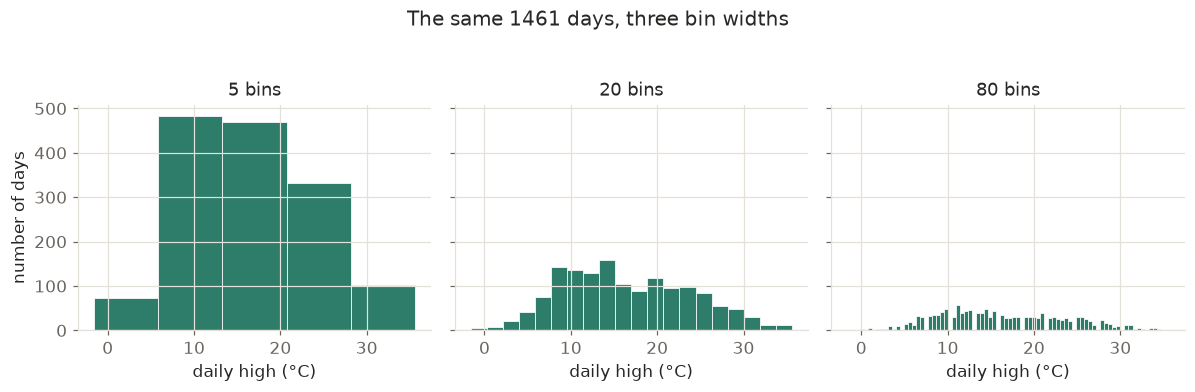

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), sharey=True)

for ax, bins in zip(axes, [5, 20, 80]):
    ax.hist(weather["temp_max"], bins=bins, color=C["accent"], edgecolor="white", linewidth=0.5)
    ax.set_title(f"{bins} bins")
    ax.set_xlabel("daily high (°C)")
axes[0].set_ylabel("number of days")

fig.suptitle("The same 1461 days, three bin widths", y=1.04)
plt.tight_layout()
plt.show()

Twenty bins is about right here. You can see the two seasons as a broad hump each, which five bins
hides and eighty bins buries in jitter.

Now put rainfall next to it. Same data set, same number of days, completely different shape.

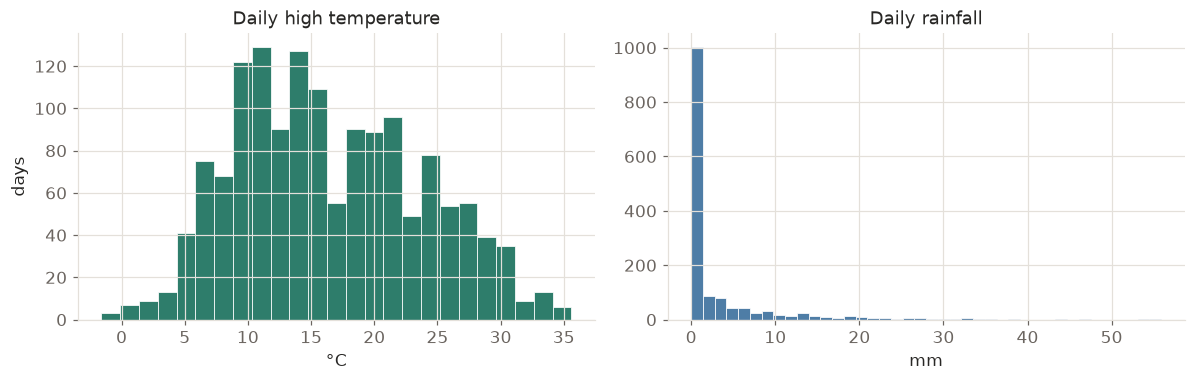

In [6]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.6))

left.hist(weather["temp_max"], bins=25, color=C["accent"], edgecolor="white", linewidth=0.5)
left.set_title("Daily high temperature"); left.set_xlabel("°C"); left.set_ylabel("days")

right.hist(weather["precipitation"], bins=40, color=C["cat3"], edgecolor="white", linewidth=0.5)
right.set_title("Daily rainfall"); right.set_xlabel("mm")

plt.tight_layout()
plt.show()

Temperature is roughly **symmetric**, with a hump in the middle and tails of similar length.
Rainfall is **skewed right**, a tall pile at zero and a long thin tail reaching out to the days it
poured. Almost every summary you compute behaves differently on those two shapes, which is why you
draw the picture before you compute anything.

In [ ]:
# Your turn.
# Draw a histogram of the wind column. Try 10, 30 and 60 bins.
# Is wind more like temperature or more like rainfall? Say why in a comment.

...

## 2.2 Center and location

Three numbers claim to describe the middle, and they answer different questions.

The **mean** is the balance point, the value you get by sharing everything out equally. The
**median** is the splitter, with half the values on each side. The **mode** is the most common
value. On a symmetric data set they nearly agree. On a skewed one they part company.

In [7]:
for column in ["temp_max", "precipitation"]:
    col = weather[column]
    print(f"{column:14s}  mean {col.mean():6.2f}   median {col.median():6.2f}   mode {col.mode()[0]:6.2f}")

temp_max        mean  16.44   median  15.60   mode  11.10
precipitation   mean   3.03   median   0.00   mode   0.00


For temperature the mean and median differ by a fifth of a degree, so either will do. For rainfall
the mean is 3.03 and the median is 0. Both are correct and they answer different questions.

"How much rain falls in a typical day?" is answered by the median, and the answer is none. "How
much rain does Seattle get in a year?" is answered by the mean times 365, and the median would tell
you zero, which is badly wrong. Neither number is the middle. You have to know which question you
are asking.

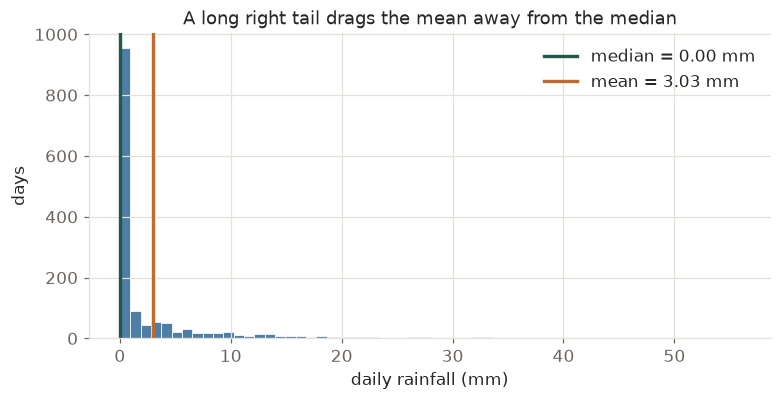

In [8]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(weather["precipitation"], bins=60, color=C["cat3"], edgecolor="white", linewidth=0.5)
ax.axvline(weather["precipitation"].median(), color=C["accent_strong"], lw=2.2,
           label=f"median = {weather['precipitation'].median():.2f} mm")
ax.axvline(weather["precipitation"].mean(), color=C["warn"], lw=2.2,
           label=f"mean = {weather['precipitation'].mean():.2f} mm")

ax.set_xlabel("daily rainfall (mm)"); ax.set_ylabel("days")
ax.set_title("A long right tail drags the mean away from the median")
ax.legend()
plt.show()

The mean is not robust. One freak day moves it, and the median barely notices. Watch what a single
invented monsoon does to each.

In [9]:
rain = weather["precipitation"]
with_flood = pd.concat([rain, pd.Series([5000.0])])   # one absurd day

print(f"mean   {rain.mean():8.2f}  ->  {with_flood.mean():8.2f}")
print(f"median {rain.median():8.2f}  ->  {with_flood.median():8.2f}")

mean       3.03  ->      6.45
median     0.00  ->      0.00


In [ ]:
# Your turn.
# The penguins file has a body_mass_g column. Load it, then:
# 1. print the mean and the median
# 2. add one fake 10 kg penguin and print both again
# Which moved more, and does that match what you saw with rainfall?

penguins = pd.read_csv(DATA / "penguins.csv")
...

## 2.3 Box plots and skewness

A **box plot** is the five-number summary drawn. The box runs from the first quartile $Q_1$ to the
third quartile $Q_3$, a line marks the median, and the whiskers reach out to the furthest points
within 1.5 box-widths. Anything past that is drawn as an individual dot.

The box holds the middle half of the data, so its width, $Q_3 - Q_1$, is the **interquartile range**.
Where the median sits inside the box tells you the skew.

In [10]:
q = weather["precipitation"].quantile([0.25, 0.5, 0.75])
print(f"Q1 = {q[0.25]:.2f}   median = {q[0.5]:.2f}   Q3 = {q[0.75]:.2f}   IQR = {q[0.75] - q[0.25]:.2f}")

Q1 = 0.00   median = 0.00   Q3 = 2.80   IQR = 2.80


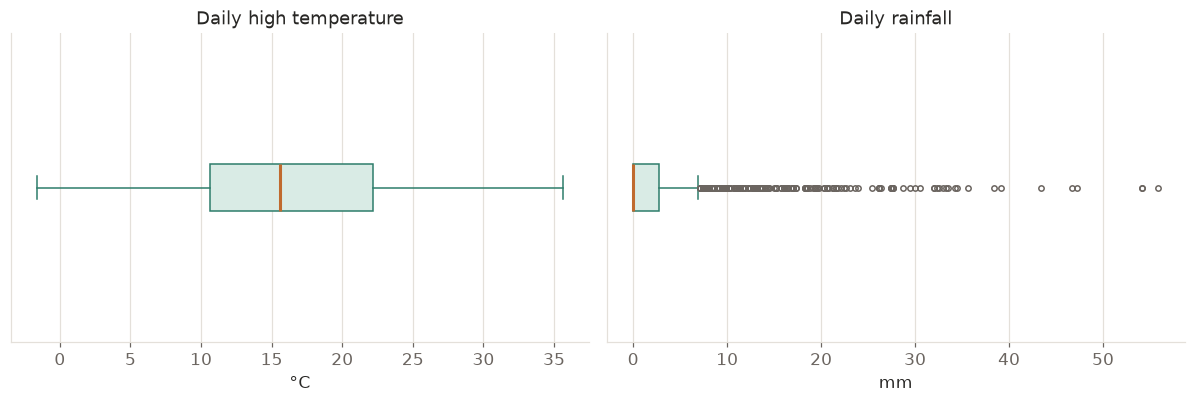

In [11]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.8))

style = dict(patch_artist=True, medianprops=dict(color=C["warn"], linewidth=2),
             boxprops=dict(facecolor=C["accent_soft"], edgecolor=C["accent"]),
             whiskerprops=dict(color=C["accent"]), capprops=dict(color=C["accent"]),
             flierprops=dict(marker="o", markersize=3.5, markerfacecolor="none",
                             markeredgecolor=C["ink_soft"]))

left.boxplot(weather["temp_max"], orientation="horizontal", **style)
left.set_title("Daily high temperature"); left.set_xlabel("°C"); left.set_yticks([])

right.boxplot(weather["precipitation"], orientation="horizontal", **style)
right.set_title("Daily rainfall"); right.set_xlabel("mm"); right.set_yticks([])

plt.tight_layout()
plt.show()

The temperature box is nearly centred on its median with whiskers of similar length, which is what
symmetry looks like. The rainfall box is squashed against zero with a long right whisker and a
crowd of outlier dots, which is what a right skew looks like.

Box plots earn their keep when you compare groups. Here is rainfall split by the weather label.

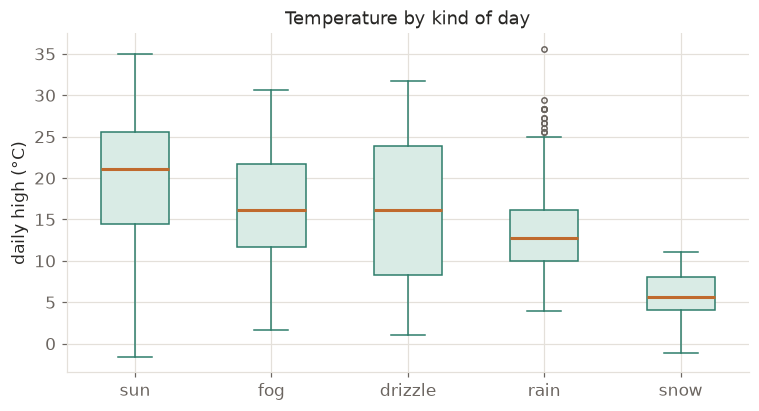

In [12]:
kinds = ["sun", "fog", "drizzle", "rain", "snow"]
groups = [weather.loc[weather["weather"] == k, "temp_max"] for k in kinds]

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(groups, tick_labels=kinds, **style)
ax.set_ylabel("daily high (°C)")
ax.set_title("Temperature by kind of day")
plt.show()

In [ ]:
# Your turn.
# Make the same comparison for wind instead of temp_max.
# Which kind of day is windiest, and is the difference bigger or smaller than for temperature?

...

## 2.4 Spread

Center is half the story. Two data sets can share a mean and be nothing alike.

Each value's distance from the mean is its **deviation**, $x_i - \bar{x}$. Those always add to zero,
so to measure spread we square them first. The **variance** is the average square, and the
**standard deviation** is its square root, which puts the number back into the original units.

$$s = \sqrt{\frac{\sum (x_i - \bar{x})^2}{n - 1}}$$

We divide by $n - 1$ rather than $n$ because the mean was estimated from the same data. Pandas does
that by default, and numpy does not, which is a classic way to lose an hour.

In [13]:
temp = weather["temp_max"]

deviations = temp - temp.mean()
print(f"deviations sum to {deviations.sum():.10f}")
print()
print(f"pandas  .std()            = {temp.std():.4f}   (divides by n - 1)")
print(f"numpy   .std()            = {np.std(temp):.4f}   (divides by n)")
print(f"numpy   .std(ddof=1)      = {np.std(temp, ddof=1):.4f}   (matches pandas)")

deviations sum to -0.0000000000

pandas  .std()            = 7.3498   (divides by n - 1)
numpy   .std()            = 7.3472   (divides by n)
numpy   .std(ddof=1)      = 7.3498   (matches pandas)


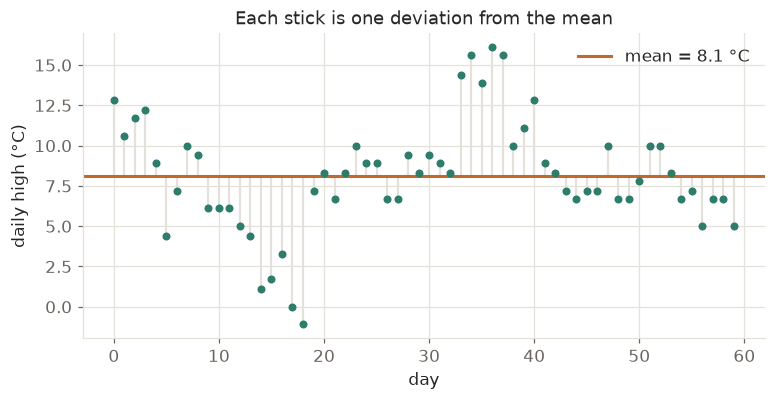

In [14]:
fig, ax = plt.subplots(figsize=(8, 3.6))
sub = temp.iloc[:60]                                  # first 60 days, so the sticks are visible
ax.vlines(range(len(sub)), sub.mean(), sub, color=C["line"], lw=1.4)
ax.scatter(range(len(sub)), sub, s=18, color=C["accent"], zorder=3)
ax.axhline(sub.mean(), color=C["warn"], lw=2, label=f"mean = {sub.mean():.1f} °C")

ax.set_xlabel("day"); ax.set_ylabel("daily high (°C)")
ax.set_title("Each stick is one deviation from the mean")
ax.legend()
plt.show()

Now compare spread across groups. Standard deviation is in the same units as the data, so you can
read it directly: a standard deviation of 7 °C means a typical day sits about 7 degrees from average.

In [15]:
penguins = pd.read_csv(DATA / "penguins.csv")

summary = penguins.groupby("species")["body_mass_g"].agg(
    n="count", mean="mean", sd="std", iqr=lambda s: s.quantile(0.75) - s.quantile(0.25))
summary.round(1)

,n,mean,sd,iqr
species,,,,
Adelie,151,3700.7,458.6,650.0
Chinstrap,68,3733.1,384.3,462.5
Gentoo,123,5076.0,504.1,800.0


Adelie and Chinstrap have almost the same mean, about 3700 g, and Chinstrap are noticeably less
varied. Gentoo are heavier than both and also more spread out. A mean on its own would have told
you the first fact and hidden the other two.

In [ ]:
# Your turn.
# 1. Compute the standard deviation of temp_max for each kind of day.
# 2. Which kind has the tightest spread? Does that make physical sense?
# 3. Now compute the same thing by hand, without .std(), using the formula:
#    sqrt(sum((x - mean)**2) / (n - 1))
#    Check your answer matches pandas.

...

## Exercises

1. **Seasons.** Add a `month` column with `weather["date"].dt.month`. Plot the mean and the median
   daily high for each month on the same axes. Where do they separate most, and what does that tell
   you about the shape of that month's data?

2. **The bin-width trap.** Draw the rainfall histogram with bin widths of 0.5 mm, 5 mm and 25 mm.
   At which width does the "half the days are dry" fact disappear?

3. **Outliers by rule.** A common rule calls a point an outlier if it lies more than
   $1.5 \times \mathrm{IQR}$ beyond a quartile. Apply it to `wind` and count how many days qualify.
   Then look at those days. Were they genuinely stormy, or is the rule just reacting to skew?

4. **Comparing like with like.** Standard deviation has units, so you cannot compare the spread of
   penguin mass in grams against flipper length in millimetres. The **coefficient of variation**,
   $s / \bar{x}$, has no units. Compute it for all four penguin measurements. Which trait varies most
   in relative terms?

5. **A summary that lies.** Build two small data sets, by hand, with the same mean and the same
   standard deviation but obviously different shapes. Plot them side by side. This is why you draw
   the picture.

## What you should take away

Shape first, then numbers. A symmetric data set is happy to be summarised by a mean and a standard
deviation. A skewed one is not, and rainfall is the proof: a mean of 3 mm and a median of 0 mm are
both true and they answer different questions.

The median and the interquartile range are **robust**, meaning one freak value barely moves them.
The mean and the standard deviation are not, which is a weakness when your data has outliers and a
strength when it does not, because they use every value rather than just the middle ones.

---

*StatLab, by Dr. Sein Minn and Kaung Hein Htet. Code MIT, text CC BY 4.0.
Follows OpenStax [Introductory Statistics](https://openstax.org) (Illowsky & Dean, CC BY 4.0).*